In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, re, math, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules')

from spk_feat_cluster_analysis import load_chunked_specparam_results, trim_edges
from config import (CELL_IDS, DICT_PATCH_FS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT, LFP_FS)

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated',
                        category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', message=r'invalid value encountered in log10',
                        category=RuntimeWarning, module=r'.*specparam.*')

In [2]:
# ── Cell configuration ────────────────────────────────────────────────────────
cell_num = 7

# Time windows for averaging LFP features
PRE_WIN  = (-0.5, -0.05)   # pre-spike: −500 ms → −50 ms
POST_WIN = (0.005, 0.055)  # post-spike: +5 ms → +55 ms  (50 ms clean window)

# Ridge regression settings
RIDGE_ALPHA = 1.0
N_PERM      = 1000   # permutation iterations; increase to 5000 for publication
RNG_SEED    = 42

## 1. Load Pickles

In [3]:
# Cluster DataFrame  (spike waveform features + log ISI)
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')
with open(cluster_pickle, 'rb') as f:
    df_features_clust = pickle.load(f)
print(f'Loaded cluster_df: {len(df_features_clust)} spikes')
print(f'  columns: {list(df_features_clust.columns)}')

Loaded cluster_df: 11997 spikes
  columns: ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi', 'spk_times_idx', 'spk_times_ms', 'spk_id', 'inflection_time_cluster', 'peak_sharpness_cluster', 'log_isi_cluster']


In [4]:
# Simple LFP pickles  (sliding-window lfp_mean, lfp_std, lfp_exponent)
simple_pickle = os.path.join(SPE1_PICKLE_ROOT, 'simple_lfp_pickles', f'c{cell_num}_simple_lfp.pkl')
with open(simple_pickle, 'rb') as f:
    lfp_windows_by_spike = pickle.load(f)
print(f'Loaded simple_lfp: {len(lfp_windows_by_spike)} spikes')
if lfp_windows_by_spike[0]:
    print(f'  keys: {list(lfp_windows_by_spike[0].keys())}')

Loaded simple_lfp: 11971 spikes
  keys: ['t_bins_s', 'lfp_mean', 'lfp_std', 'lfp_exponent']


In [5]:
# Specparam pickles  (sliding-window exponent, band AUCs, …)
chunk_dir    = os.path.join(SPE1_PICKLE_ROOT, 'multitaper_pickles', f'c{cell_num}')
chunk_prefix = f'c{cell_num}_specparam'

specparam_by_spike = load_chunked_specparam_results(save_dir=chunk_dir, prefix=chunk_prefix)
specparam_by_spike = trim_edges(specparam_by_spike, edge_sec=0.5)
print(f'Specparam ready for {len(specparam_by_spike)} spikes')

# Use the smaller count to align all three sources
n_spikes = len(specparam_by_spike)
df_reg   = df_features_clust.iloc[:n_spikes].reset_index(drop=True)
lfp_windows_by_spike = lfp_windows_by_spike[:n_spikes]
print(f'Aligned to {n_spikes} spikes')

Found 60 chunk files. Assembling master list...
Loading Chunks: 100%|██████████| 60/60 [00:09<00:00,  6.12it/s]
Success! Master list assembled with 11971 total spikes.
Specparam ready for 11971 spikes
Aligned to 11971 spikes


## 2. Build Feature and Target Matrices

**Predictors (X)** — three competing sets tested separately:
- *Waveform only*: 8 spike shape features
- *Log ISI only*: inter-spike interval (1 feature)
- *Waveform + Log ISI*: all 9 features combined

**Targets (Y)** — 10 LFP scalars, extracted as the mean over the pre- or post-spike window:

| # | Feature | Source | Window |
|---|---------|--------|--------|
| 0 | LFP amplitude | simple_lfp | pre |
| 1 | LFP std | simple_lfp | pre |
| 2 | Gamma AUC | specparam | pre |
| 3 | Aperiodic exponent | specparam | pre |
| 4 | Theta AUC | specparam | pre |
| 5 | LFP amplitude | simple_lfp | post 50 ms |
| 6 | LFP std | simple_lfp | post 50 ms |
| 7 | Gamma AUC | specparam | post 50 ms |
| 8 | Aperiodic exponent | specparam | post 50 ms |
| 9 | Theta AUC | specparam | post 50 ms |

In [6]:
def win_avg(t_bins, arr, window):
    """Mean of a 1-D array over a time window (seconds)."""
    if t_bins is None or arr is None:
        return np.nan
    t = np.asarray(t_bins, float)
    a = np.asarray(arr, float)
    mask = (t >= window[0]) & (t <= window[1])
    if not np.any(mask):
        return np.nan
    vals = a[mask]
    return float(np.nanmean(vals)) if np.any(np.isfinite(vals)) else np.nan


# ── Predictor columns ─────────────────────────────────────────────────────────
waveform_cols   = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
                   'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const']
waveform_labels = ['Ramp Amp', 'Infl. Time', 'Infl. Amp', 'Peak Amp',
                   'Peak Width', 'Sharpness', 'Decay λ', 'Decay Const']

X_waveform = df_reg[waveform_cols].values           # (n, 8)
X_log_isi  = df_reg[['log_isi']].values             # (n, 1)
X_both     = np.hstack([X_waveform, X_log_isi])     # (n, 9)

predictor_sets = {
    'Waveform only':       (X_waveform, waveform_labels),
    'Log ISI only':        (X_log_isi,  ['Log ISI']),
    'Waveform + Log ISI':  (X_both,     waveform_labels + ['Log ISI']),
}

# ── Target columns ────────────────────────────────────────────────────────────
target_names = [
    'pre_lfp_amp',  'pre_lfp_std',  'pre_gamma_auc',  'pre_exponent',  'pre_theta_auc',
    'post_lfp_amp', 'post_lfp_std', 'post_gamma_auc', 'post_exponent', 'post_theta_auc',
]
target_labels = [
    'Pre LFP Amp',  'Pre LFP Std',  'Pre Gamma AUC',  'Pre Exponent',  'Pre Theta AUC',
    'Post LFP Amp', 'Post LFP Std', 'Post Gamma AUC', 'Post Exponent', 'Post Theta AUC',
]

Y = np.full((n_spikes, len(target_names)), np.nan)

for i in range(n_spikes):
    sp        = specparam_by_spike[i]
    sw        = lfp_windows_by_spike[i]
    t_sp      = sp.get('t_bins_s')    if sp else None
    t_sw      = sw['t_bins_s']        if sw is not None else None
    band_aucs = sp.get('band_aucs', {}) if sp else {}

    for col_off, WIN in [(0, PRE_WIN), (5, POST_WIN)]:
        Y[i, col_off + 0] = win_avg(t_sw, sw['lfp_mean']          if sw else None, WIN)
        Y[i, col_off + 1] = win_avg(t_sw, sw['lfp_std']           if sw else None, WIN)
        Y[i, col_off + 2] = win_avg(t_sp, band_aucs.get('gamma'),                  WIN)
        Y[i, col_off + 3] = win_avg(t_sp, sp.get('exponent')      if sp else None, WIN)
        Y[i, col_off + 4] = win_avg(t_sp, band_aucs.get('theta'),                  WIN)

nan_pct = np.isnan(Y).mean(axis=0) * 100
print('Target NaN %:')
for tl, pct in zip(target_labels, nan_pct):
    print(f'  {tl:20s}  {pct:.1f}%')

Target NaN %:
  Pre LFP Amp           0.0%
  Pre LFP Std           0.0%
  Pre Gamma AUC         0.0%
  Pre Exponent          0.0%
  Pre Theta AUC         0.0%
  Post LFP Amp          0.0%
  Post LFP Std          0.0%
  Post Gamma AUC        0.0%
  Post Exponent         0.0%
  Post Theta AUC        0.0%


## 3. Ridge Regression with Permutation Test

For each of the 10 LFP targets and each of the 3 predictor sets:
1. Standardise X and y (z-score) so beta weights are comparable
2. Fit `Ridge(alpha=1.0)` on all valid spikes
3. Compute R² (squared Pearson r between actual and predicted)
4. Permutation test: shuffle y `N_PERM` times and refit → empirical null distribution

In [7]:
# results[target_name][pred_set_name] = dict(r2, p_val, null_mean, null_std, beta, n_valid)
results = {tname: {} for tname in target_names}

for t_idx, (tname, tlabel) in enumerate(zip(target_names, target_labels)):
    y_raw = Y[:, t_idx]

    for p_idx, (pname, (X_raw_p, plabels)) in enumerate(predictor_sets.items()):
        valid = np.isfinite(X_raw_p).all(axis=1) & np.isfinite(y_raw)
        n_valid = int(valid.sum())

        if n_valid < 20:
            results[tname][pname] = dict(r2=np.nan, p_val=np.nan,
                                         null_mean=np.nan, null_std=np.nan,
                                         beta=None, n_valid=n_valid)
            continue

        X, y = X_raw_p[valid], y_raw[valid]

        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_z = scaler_X.fit_transform(X)
        y_z = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

        ridge = Ridge(alpha=RIDGE_ALPHA)
        ridge.fit(X_z, y_z)
        y_pred_z = ridge.predict(X_z)
        r2 = float(np.corrcoef(y_z, y_pred_z)[0, 1] ** 2)

        # Each (target, predictor) pair gets its own independently seeded RNG so
        # null distributions are truly independent and p-values reflect the actual
        # relationship for that specific (X, y) combination — not correlated across features.
        rng = np.random.default_rng([RNG_SEED, t_idx, p_idx])
        perm_r2 = np.empty(N_PERM)
        for pi in range(N_PERM):
            y_perm = rng.permutation(y_z)
            _r = Ridge(alpha=RIDGE_ALPHA)
            _r.fit(X_z, y_perm)
            perm_r2[pi] = float(np.corrcoef(y_perm, _r.predict(X_z))[0, 1] ** 2)

        p_val = (np.sum(perm_r2 >= r2) + 1) / (N_PERM + 1)

        results[tname][pname] = dict(
            r2=r2, p_val=p_val,
            null_mean=float(np.mean(perm_r2)),
            null_std=float(np.std(perm_r2)),
            beta=dict(zip(plabels, ridge.coef_)),
            n_valid=n_valid,
        )

# ── Summary table with null-distribution diagnostics ─────────────────────────
# Null µ±σ should vary across targets/predictors, confirming p-values are distinct.
print(f'c{cell_num} Ridge Regression Summary  (N_PERM={N_PERM})')
print(f'Columns: observed R²* and null µ±σ  (* = p<0.05 permutation)\n')

col_w = 26
header = f'{"Target":<22}' + ''.join(f'{n:>{col_w}}' for n in predictor_sets.keys())
print(header)
print('-' * len(header))

for tname, tlabel in zip(target_names, target_labels):
    def fmt_cell(pname):
        res = results[tname].get(pname, {})
        r  = res.get('r2',        np.nan)
        p  = res.get('p_val',     np.nan)
        nm = res.get('null_mean', np.nan)
        ns = res.get('null_std',  np.nan)
        if not np.isfinite(r):
            return 'NaN'
        star = '*' if (np.isfinite(p) and p < 0.05) else ' '
        return f'{r:.4f}{star} ({nm:.4f}±{ns:.4f})'

    row = f'{tlabel:<22}' + ''.join(f'{fmt_cell(pn):>{col_w}}' for pn in predictor_sets.keys())
    print(row)

print('\nNote: null µ±σ values differ per (target, predictor) pair because each uses')
print('an independently seeded RNG — p-values are not shared across features.')

c7 Ridge Regression Summary  (N_PERM=1000)
Columns: observed R²* and null µ±σ  (* = p<0.05 permutation)

Target                             Waveform only              Log ISI only        Waveform + Log ISI
----------------------------------------------------------------------------------------------------
Pre LFP Amp              0.1011* (0.0007±0.0003)   0.0010* (0.0001±0.0001)   0.1013* (0.0007±0.0004)
Pre LFP Std              0.0344* (0.0007±0.0003)   0.0010* (0.0001±0.0001)   0.0344* (0.0008±0.0004)
Pre Gamma AUC            0.0054* (0.0007±0.0003)   0.0000  (0.0001±0.0001)   0.0055* (0.0007±0.0004)
Pre Exponent             0.0028* (0.0007±0.0003)   0.0001  (0.0001±0.0001)   0.0028* (0.0007±0.0004)
Pre Theta AUC            0.0053* (0.0007±0.0003)   0.0004* (0.0001±0.0001)   0.0054* (0.0008±0.0004)
Post LFP Amp             0.1010* (0.0006±0.0003)   0.0010* (0.0001±0.0001)   0.1012* (0.0008±0.0003)
Post LFP Std             0.0179* (0.0007±0.0003)   0.0018* (0.0001±0.0001)   0.0187* (0

## 4. Summary Visualization

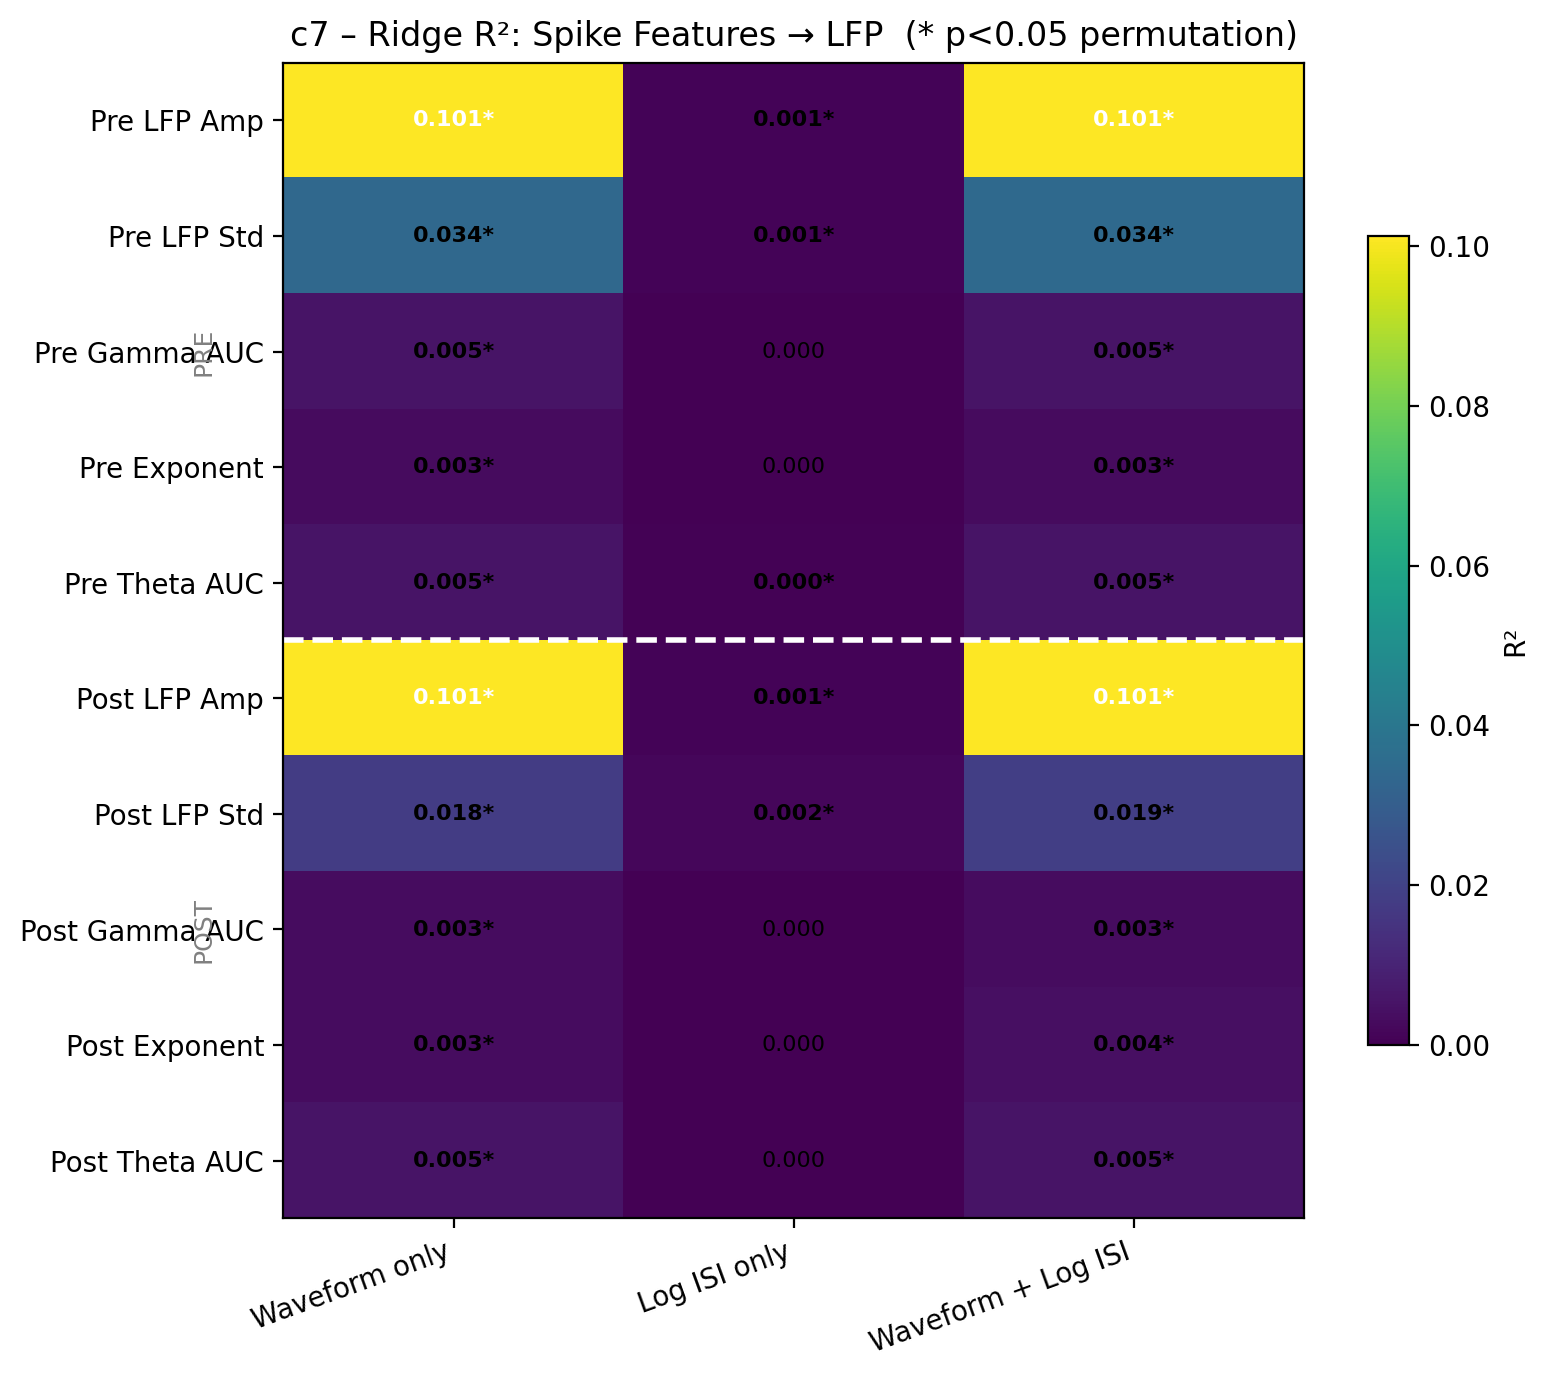

In [8]:
# ── R² heatmap: targets × predictor sets ──────────────────────────────────────
pred_names = list(predictor_sets.keys())
n_t = len(target_names)
n_p = len(pred_names)

r2_mat   = np.full((n_t, n_p), np.nan)
pval_mat = np.full((n_t, n_p), np.nan)

for t_idx, tname in enumerate(target_names):
    for p_idx, pname in enumerate(pred_names):
        res = results[tname].get(pname, {})
        r2_mat[t_idx, p_idx]   = res.get('r2', np.nan)
        pval_mat[t_idx, p_idx] = res.get('p_val', np.nan)

vmax = np.nanmax(r2_mat) if np.any(np.isfinite(r2_mat)) else 0.1
vmax = max(vmax, 0.01)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(r2_mat, aspect='auto', vmin=0, vmax=vmax, cmap='viridis')

ax.set_xticks(range(n_p))
ax.set_xticklabels(pred_names, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(n_t))
ax.set_yticklabels(target_labels, fontsize=10)

# Add R² values and significance stars
for r in range(n_t):
    for c in range(n_p):
        v = r2_mat[r, c]
        p = pval_mat[r, c]
        if np.isfinite(v):
            star = '*' if (np.isfinite(p) and p < 0.05) else ''
            txt_col = 'white' if v > vmax * 0.55 else 'black'
            ax.text(c, r, f'{v:.3f}{star}', ha='center', va='center',
                    fontsize=8, color=txt_col, fontweight='bold' if star else 'normal')

# Horizontal line separating pre / post
ax.axhline(4.5, color='white', lw=2, linestyle='--')
ax.text(-0.7, 2.0, 'PRE', va='center', ha='right', fontsize=9, color='gray', rotation=90)
ax.text(-0.7, 7.0, 'POST', va='center', ha='right', fontsize=9, color='gray', rotation=90)

plt.colorbar(im, ax=ax, label='R²', shrink=0.7)
ax.set_title(f'c{cell_num} – Ridge R²: Spike Features → LFP  (* p<0.05 permutation)', fontsize=12)
fig.tight_layout()
plt.show()

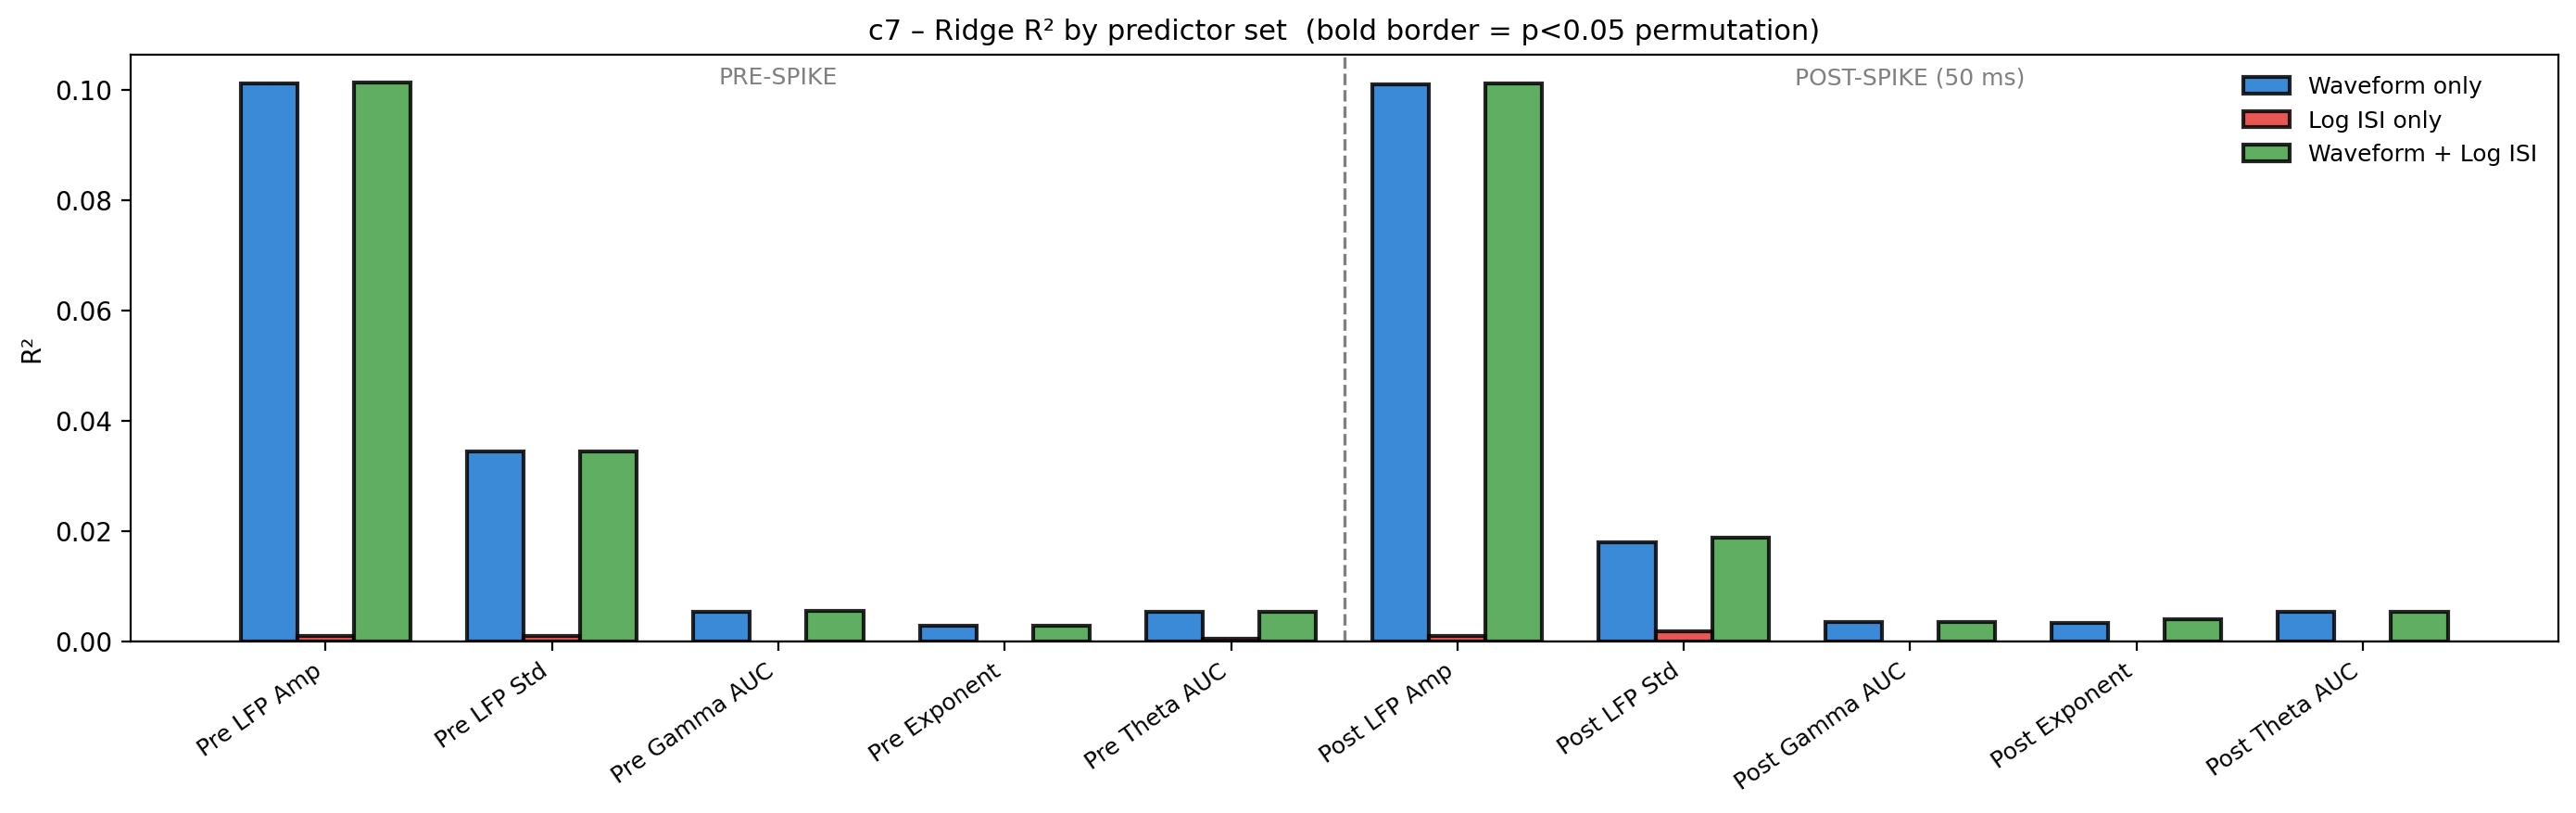

In [9]:
# ── Bar chart: R² per target, grouped by predictor set ────────────────────────
x   = np.arange(n_t)
bw  = 0.25
bar_colors = ['#1976D2', '#E53935', '#43A047']

fig, ax = plt.subplots(figsize=(14, 4.5))
for p_idx, (pname, col) in enumerate(zip(pred_names, bar_colors)):
    vals = r2_mat[:, p_idx]
    bars = ax.bar(x + (p_idx - 1) * bw, vals, width=bw, label=pname,
                  color=col, alpha=0.85)
    # significance hatch
    for b_i, bar in enumerate(bars):
        p = pval_mat[b_i, p_idx]
        if np.isfinite(p) and p < 0.05:
            bar.set_edgecolor('black')
            bar.set_linewidth(1.5)

ax.set_xticks(x)
ax.set_xticklabels(target_labels, rotation=35, ha='right', fontsize=9)
ax.axhline(0, color='k', lw=0.8)

# Vertical line separating pre / post
ax.axvline(4.5, color='gray', lw=1.2, linestyle='--')
ax.text(2.0, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0.05,
        'PRE-SPIKE', ha='center', fontsize=9, color='gray')
ax.text(7.0, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0.05,
        'POST-SPIKE (50 ms)', ha='center', fontsize=9, color='gray')

ax.set_ylabel('R²')
ax.legend(frameon=False, fontsize=9)
ax.set_title(f'c{cell_num} – Ridge R² by predictor set  (bold border = p<0.05 permutation)', fontsize=11)
fig.tight_layout()
plt.show()

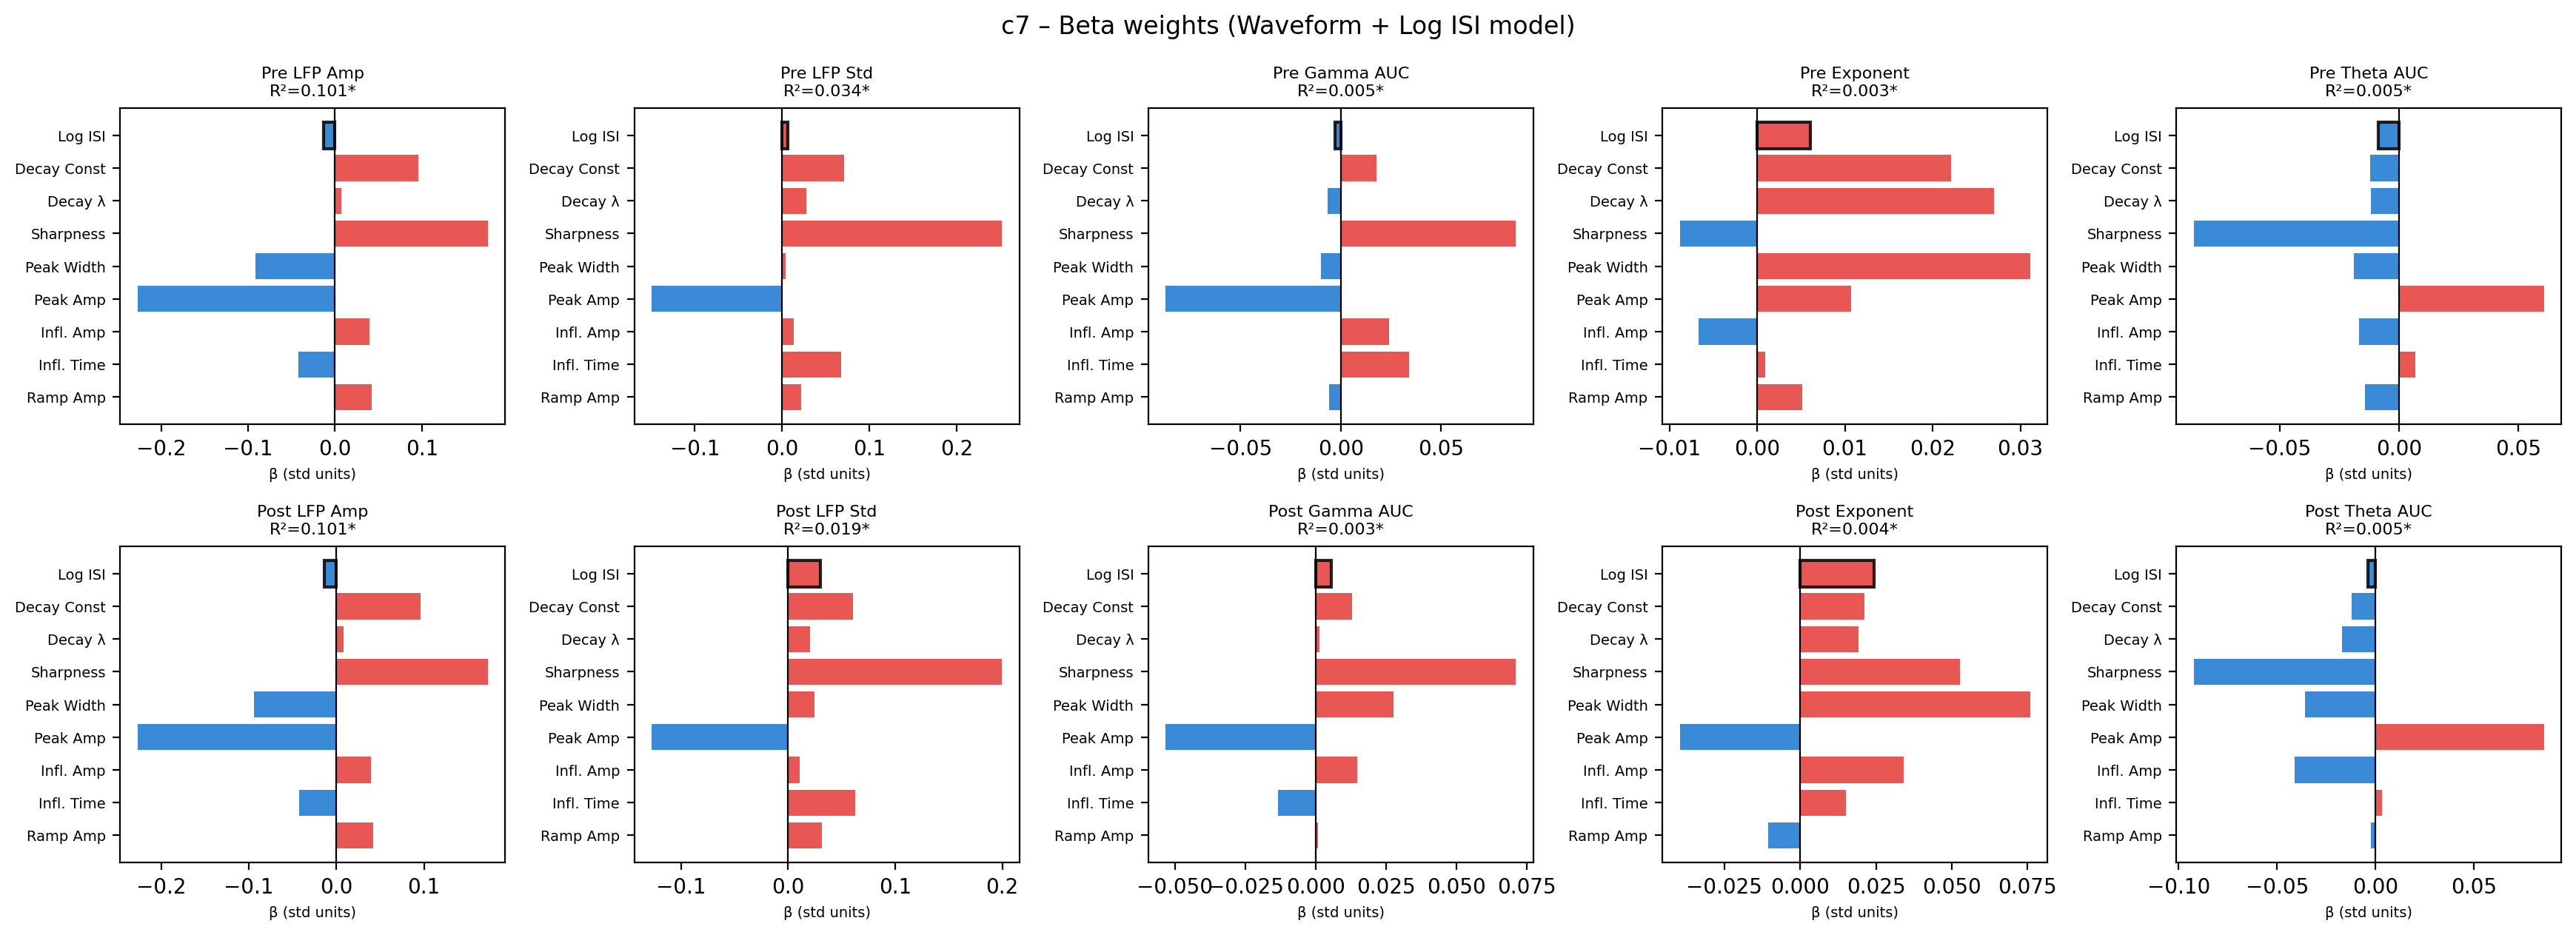

In [10]:
# ── Beta weights for 'Waveform + Log ISI' model, one subplot per target ────────
pname_both = 'Waveform + Log ISI'
both_labels = waveform_labels + ['Log ISI']
n_beta = len(both_labels)

ncols = 5
nrows = math.ceil(n_t / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2), sharey=False)
axes = axes.flatten()
fig.suptitle(f'c{cell_num} – Beta weights (Waveform + Log ISI model)', fontsize=12)

for t_idx, (tname, tlabel) in enumerate(zip(target_names, target_labels)):
    ax = axes[t_idx]
    res = results[tname].get(pname_both, {})
    beta = res.get('beta')
    r2   = res.get('r2', np.nan)
    p    = res.get('p_val', np.nan)

    if beta is None:
        ax.set_title(tlabel, fontsize=9)
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                transform=ax.transAxes, fontsize=8, color='gray')
        ax.axis('off')
        continue

    vals = [beta.get(lbl, np.nan) for lbl in both_labels]
    colors_b = ['#E53935' if v > 0 else '#1976D2' for v in vals]
    y_pos = np.arange(n_beta)

    ax.barh(y_pos, vals, color=colors_b, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(both_labels, fontsize=7)
    ax.axvline(0, color='k', lw=0.8)
    star = '*' if (np.isfinite(p) and p < 0.05) else ''
    ax.set_title(f'{tlabel}\nR²={r2:.3f}{star}', fontsize=8)
    ax.set_xlabel('β (std units)', fontsize=7)

    # Highlight log ISI bar
    ax.get_children()[n_beta - 1].set_edgecolor('black')
    ax.get_children()[n_beta - 1].set_linewidth(1.5)

# Hide unused subplots
for i in range(n_t, len(axes)):
    axes[i].set_visible(False)

fig.tight_layout()
plt.show()

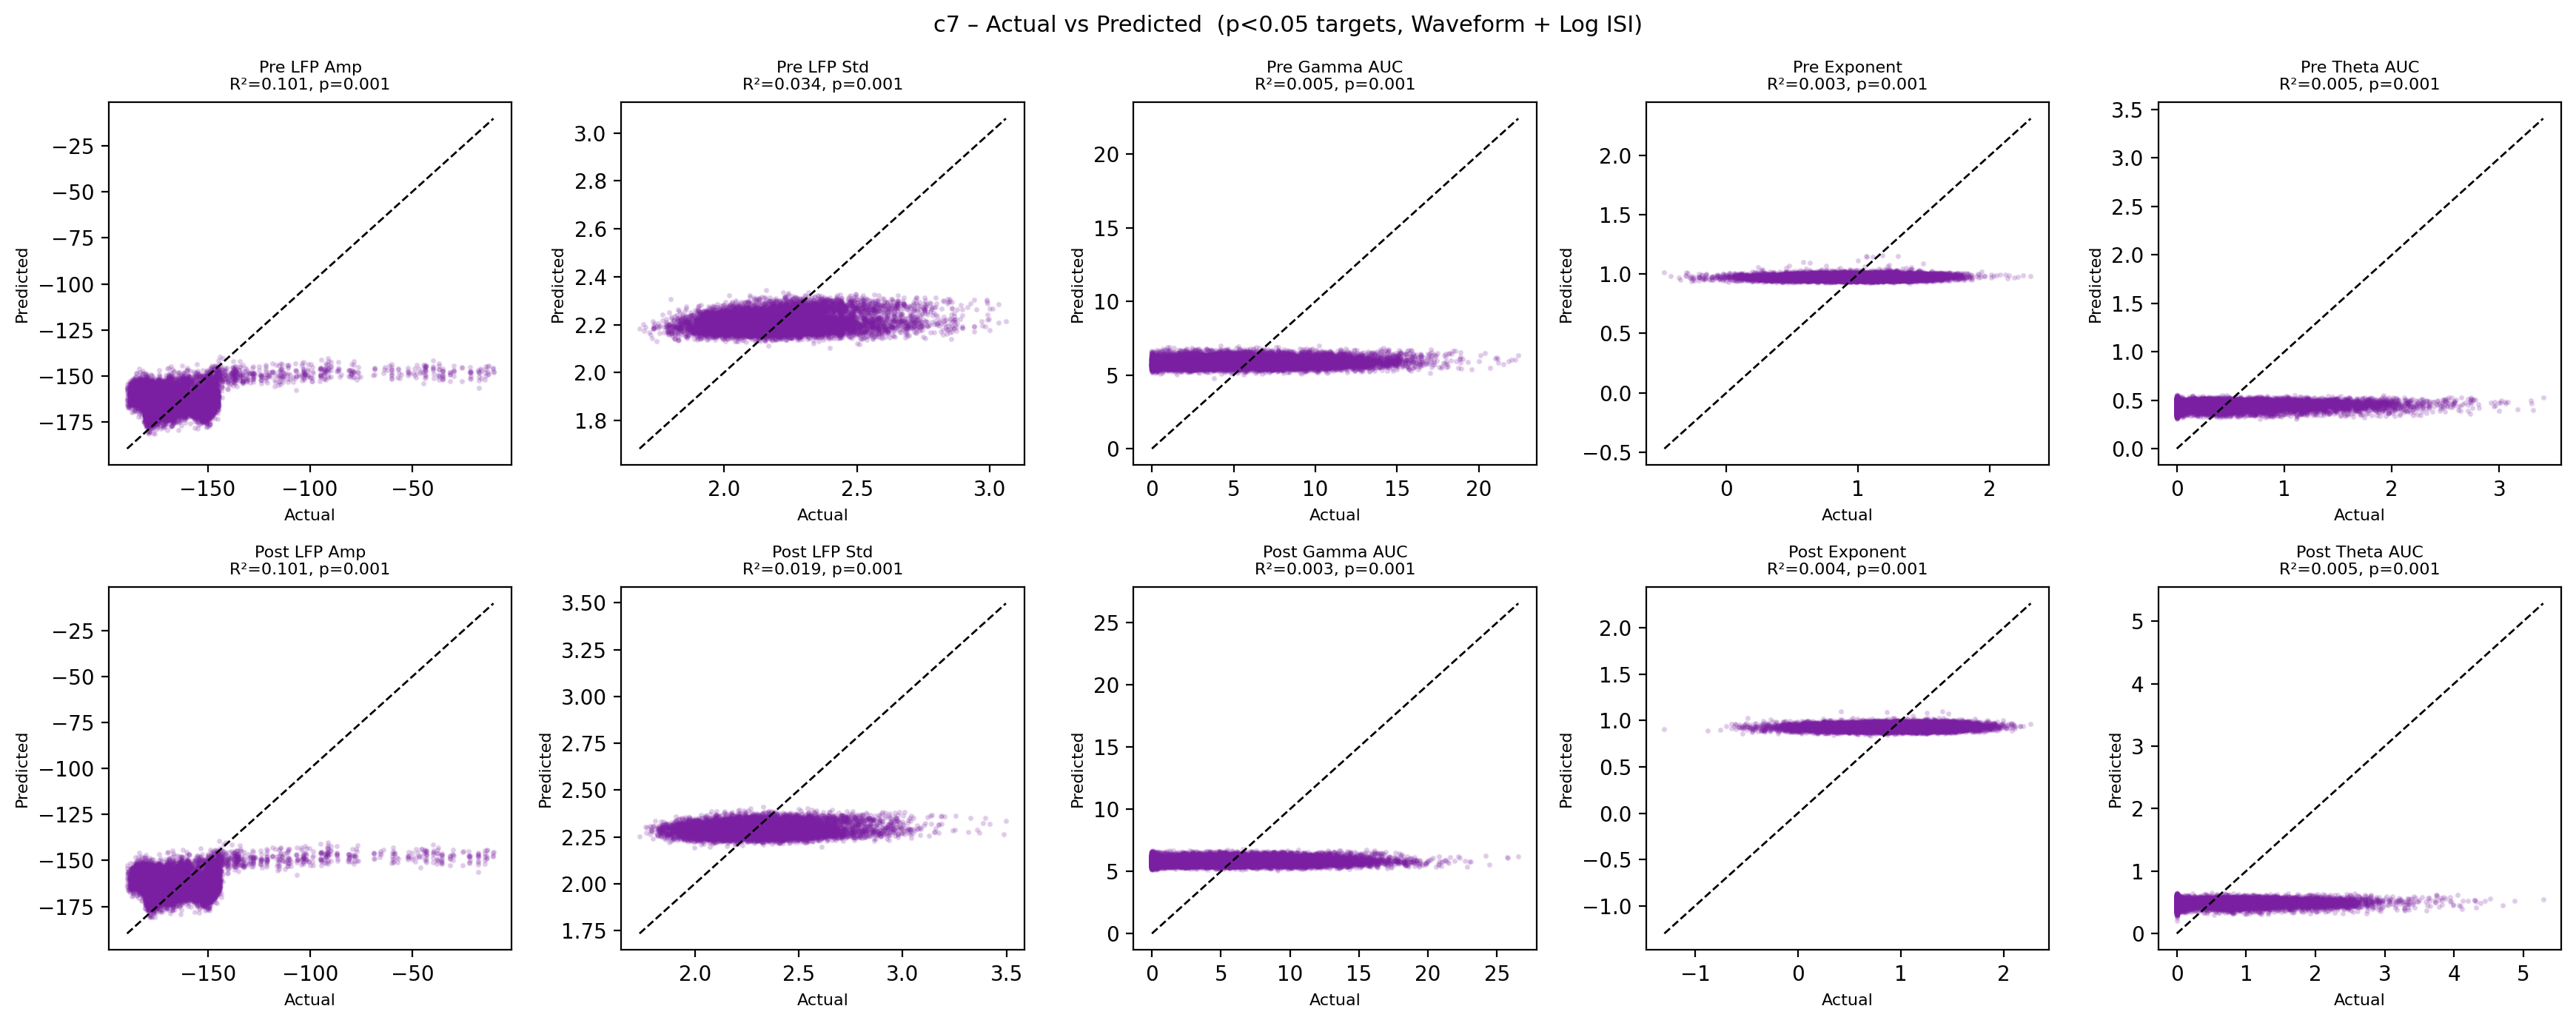

In [11]:
# ── Scatter plots: actual vs predicted for significant targets (Waveform + LogISI) ─
sig_targets = [
    (t_idx, tname, tlabel)
    for t_idx, (tname, tlabel) in enumerate(zip(target_names, target_labels))
    if results[tname].get(pname_both, {}).get('p_val', 1) < 0.05
]

if not sig_targets:
    print('No significant targets at p<0.05 for the Waveform + Log ISI model.')
else:
    ncols = min(len(sig_targets), 5)
    nrows = math.ceil(len(sig_targets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = np.array(axes).flatten() if len(sig_targets) > 1 else [axes]
    fig.suptitle(f'c{cell_num} – Actual vs Predicted  (p<0.05 targets, Waveform + Log ISI)', fontsize=11)

    for ax, (t_idx, tname, tlabel) in zip(axes, sig_targets):
        res   = results[tname][pname_both]
        y_raw = Y[:, t_idx]
        X_raw_p = X_both
        valid = np.isfinite(X_raw_p).all(axis=1) & np.isfinite(y_raw)
        X, y = X_raw_p[valid], y_raw[valid]

        X_z = StandardScaler().fit_transform(X)
        scaler_y = StandardScaler()
        y_z = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
        ridge_plot = Ridge(alpha=RIDGE_ALPHA)
        ridge_plot.fit(X_z, y_z)
        y_pred = scaler_y.inverse_transform(ridge_plot.predict(X_z).reshape(-1, 1)).ravel()

        ax.scatter(y, y_pred, alpha=0.15, s=3, rasterized=True, color='#7B1FA2')
        lo, hi = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_xlabel('Actual', fontsize=8)
        ax.set_ylabel('Predicted', fontsize=8)
        r2 = res.get('r2', np.nan)
        p  = res.get('p_val', np.nan)
        ax.set_title(f'{tlabel}\nR²={r2:.3f}, p={p:.3f}', fontsize=8)

    for i in range(len(sig_targets), len(axes)):
        axes[i].set_visible(False)

    fig.tight_layout()
    plt.show()